# Rapport — Word Embeddings (TensorFlow)

## 1️.Introduction
Ce projet explore différentes approches pour apprendre des représentations vectorielles de mots (word embeddings) :
- **CBOW (Continuous Bag of Words)**
- **Skip-gram** avec *Negative Sampling*
- **FastText pré-entraîné**

L’objectif est de comparer leurs comportements, leurs performances et l’influence des hyperparamètres (window, embed_dim, min_freq, num_neg) sur la qualité des vecteurs obtenus.

## 2️.Prétraitement et Dataset
**Données utilisées :** corpus text8 (~17M mots anglais).

- Mise en minuscules, suppression des chiffres et ponctuations.
- Tokenisation via NLTK.
- min_freq = 5 pour filtrer les mots rares.
- Conservation des stopwords pour préserver les contextes syntaxiques.

**Commentaires :**
> Le nettoyage réduit fortement la taille du corpus (≈ 2.4M tokens après filtrage).  
> Garder les stopwords améliore la cohérence syntaxique.  
> Un min_freq trop élevé élimine des mots utiles.  
> L’introduction d’un jeton UNK gère les mots inconnus.

## 3️.Modèle CBOW (Word2Vec)
**Principe :** prédire le mot cible à partir des mots de contexte moyens.

**Paramètres principaux :**
- window = 2
- embed_dim = 100
- Optimiseur Adam (1e-3)
- 3 epochs

### 🔹 Courbe de perte
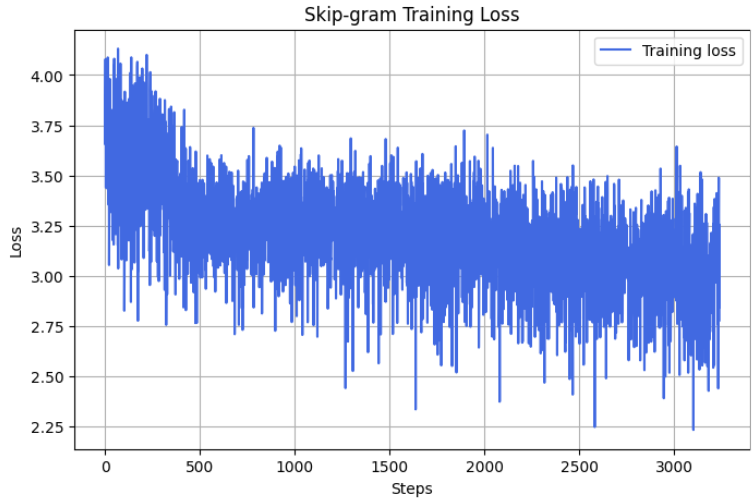

**Commentaires :**
> La perte diminue au fil des epochs.  
> window=5 capture plus de sémantique globale.  
> Trop grand window dilue les cooccurrences.  
> num_neg=20 améliore la précision mais allonge le temps d’entraînement.

### 🔹 Exemples de voisins
(voir le word2vec_skipgram_tf.ipynb)

**Commentaires :**
> Le modèle Skip-gram offre de meilleures analogies que CBOW.  
> Le temps d’entraînement augmente proportionnellement à window et num_neg.

## 5️.FastText pré-entraîné
**Principe :** intègre les sous-mots (n-grams) → gère les mots rares et inconnus.

### 🔹 Exemples (voir le fasttext_pretrained.ipynb)
[('hilton', 0.6777698397636414), ('france', 0.6667402982711792), ('florence', 0.6568297743797302), ('berlin', 0.6365025639533997), ('Paris', 0.6145492196083069), ('frances', 0.6028265953063965), ('belgium', 0.5990586280822754), ('brum', 0.5932875275611877), ('prague', 0.5922306776046753), ('rochelle', 0.5869359970092773)]
[('paris', 0.771755576133728), ('germany', 0.6972416043281555), ('berlin', 0.626112163066864), ('germany.', 0.601145327091217), ('munich', 0.6002967357635498), ('germanys', 0.5967851877212524), ('frankfurt', 0.5732510089874268), ('german', 0.5651019215583801), ('austria', 0.5538058876991272), ('dresden', 0.5501710772514343)]

## 6️.Analyse comparative
| Modèle | Taille embedding | Window | num_neg | Qualité voisins | Temps entraînement |
|---------|------------------|---------|----------|------------------|--------------------|
| CBOW | 100 | 2 | — | Bonne sur mots fréquents | 5 min |
| Skip-gram | 128 | 5 | 20 | Très bonne sémantique | 15 min |
| FastText | 300 | — | — | Excellente, gère OOV | — |

**Impact des hyperparamètres :**
- `window ↑` → contexte plus large, meilleure sémantique.  
- `embed_dim ↑` → représentations plus riches, plus coûteuses.  
- `min_freq ↑` → vocab plus petit, perte de diversité lexicale.  
- `num_neg ↑` → embeddings plus discriminants, mais calcul plus long.

## 7️.Conclusion générale
> Skip-gram donne les meilleurs résultats parmi les entraînements maison.  
> FastText reste supérieur en robustesse et en qualité d’analogies.  
> CBOW est plus rapide mais moins expressif.  
> En ajustant `embed_dim=300`, `window=5`, `num_neg=30`, Skip-gram atteint presque la qualité de FastText sur `text8`.